<a href="https://colab.research.google.com/github/gregoirehendrix/Master_Thesis/blob/main/towers_layout_groups_horizontal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Amount of CSP unit per power block : 20
Maximl amount of units per group: 3

=== RÉSULTAT ===


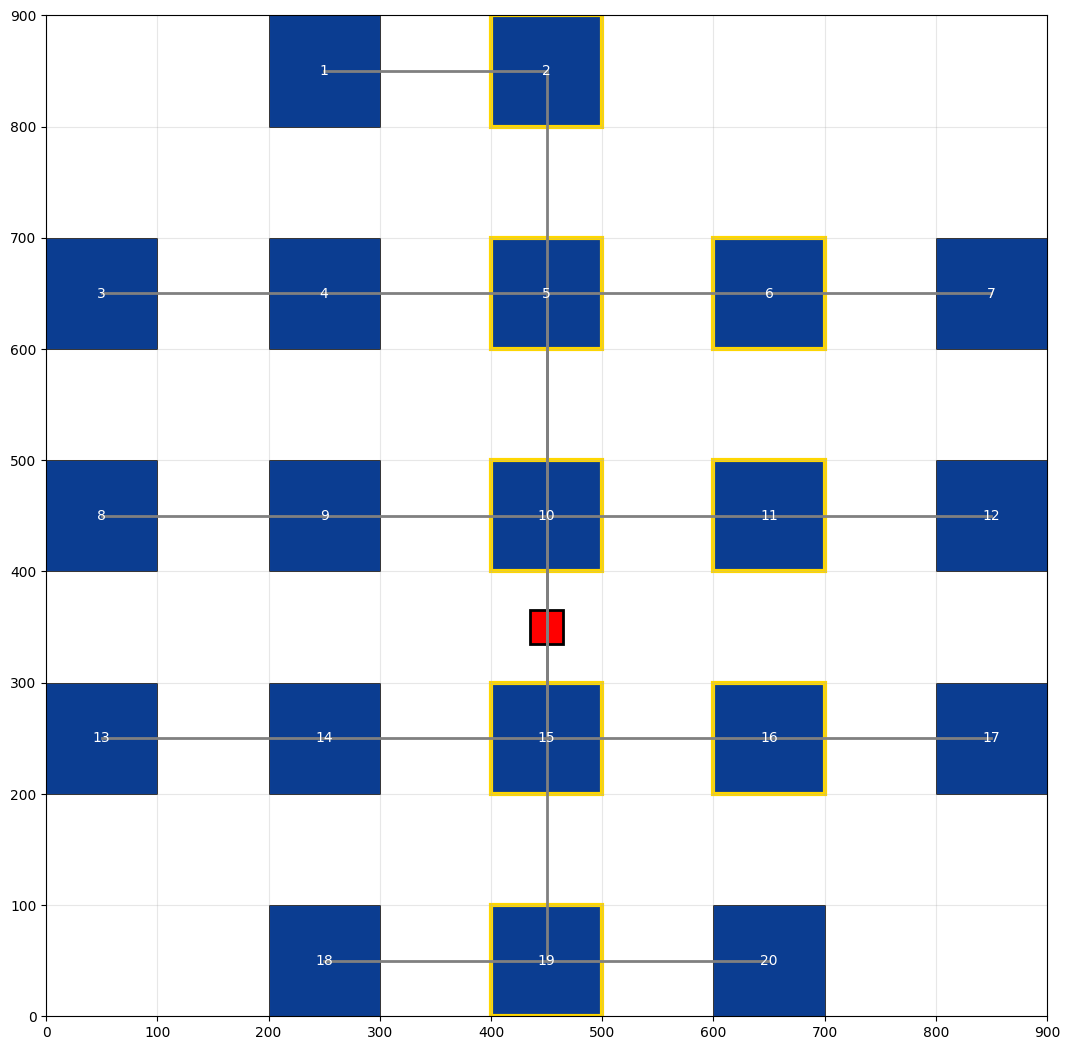

Total piping length : 4800.0 m
Average piping length per unit : 240.0

=== CLUSTERS (numérotation visuelle) ===
Hub 2 → [1, 2]
Hub 5 → [3, 4, 5]
Hub 6 → [6, 7]
Hub 10 → [8, 9, 10]
Hub 11 → [11, 12]
Hub 15 → [13, 14, 15]
Hub 16 → [16, 17]
Hub 19 → [18, 19, 20]

Total length per diameter
1 1/4" : 1800.00 m
2 1/2" : 800.00 m
2" : 2200.00 m


In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# CLASSE OPTIMISATEUR

class CSPOptimizerRows:
    def __init__(self, DIST, CAP):
        self.DIST = DIST
        self.CAP = CAP

    def coord(self, p):
        i, j = p
        return (j * self.DIST, i * self.DIST)

    def manhattan(self, a, b):
        return abs(a[0] - b[0]) + abs(a[1] - b[1])

    def generate_blue_towers(self, nb):
        n_side = math.ceil(math.sqrt(nb))
        M = n_side * 2 - 1
        positions = [(i, j) for i in range(0, M, 2)
                           for j in range(0, M, 2)]

        L = (M - 1) * self.DIST
        cx, cy = L/2, L/2
        coords = np.array([self.coord(p) for p in positions])
        dist_center = np.sqrt((coords[:,0]-cx)**2 + (coords[:,1]-cy)**2)

        sel = np.argsort(dist_center)[:nb]
        return [positions[i] for i in sel], M

    def group_by_rows(self, blue_pos):

        ordered = sorted(
            list(enumerate(blue_pos, start=1)),
            key=lambda x: (x[1][0], x[1][1])
        )

        clusters = []
        row = None
        buffer = []

        for idx, pos in ordered:
            r, c = pos

            if row is None:
                row = r

            if r != row:
                for k in range(0, len(buffer), self.CAP):
                    clusters.append(buffer[k:k+self.CAP])
                buffer = []
                row = r

            buffer.append(idx)

        for k in range(0, len(buffer), self.CAP):
            clusters.append(buffer[k:k+self.CAP])

        return clusters

    def mst_with_hub(self, nodes, coords, hub):
        if len(nodes) == 1:
            return {}

        visited = {hub}
        unvisited = set(n for n in nodes if n != hub)
        parent = {}

        while unvisited:
            best = None
            best_d = math.inf

            for u in visited:
                for v in unvisited:
                    d = self.manhattan(coords[u], coords[v])
                    if d < best_d:
                        best_d = d
                        best = (u, v)

            u, v = best
            parent[v] = u
            visited.add(v)
            unvisited.remove(v)

        return parent

    def build_network_for_pb(self, blue_pos, clusters, pb):

        coords = {}
        coords[0] = self.coord(pb)

        for i in range(1, len(blue_pos)+1):
            coords[i] = self.coord(blue_pos[i-1])

        pb_coord = coords[0]

        parent = {}
        cluster_map = {}

        for cluster in clusters:
            hub = min(cluster, key=lambda i: self.manhattan(coords[i], pb_coord))
            mst_parent = self.mst_with_hub(cluster, coords, hub)

            for v, u in mst_parent.items():
                parent[v] = u

            parent[hub] = 0
            cluster_map[hub] = cluster

        total = 0
        for b, p in parent.items():
            total += self.manhattan(coords[b], coords[p])

        return parent, coords, cluster_map, total

    def find_best_pb(self, blue_pos, M):

        clusters = self.group_by_rows(blue_pos)
        blue_set = set(blue_pos)

        candidates = [(i,j) for i in range(M) for j in range(M)
                      if (i,j) not in blue_set]

        best = None

        for pb in candidates:
            parent, coords, info, cost = self.build_network_for_pb(
                blue_pos, clusters, pb
            )
            if best is None or cost < best["cost"]:
                best = dict(pb=pb, parent=parent, coords=coords,
                            clusters=info, cost=cost)

        return best


# CALCUL CHARGES + DIAMETRES + LONGUEURS

DIAM_TABLE = {
    1: '1 1/4"',
    2: '2"',
    3: '2 1/2"',
    4: '3"',
    5: '3"'
}

def compute_pipe_charges_and_diameters(parent, nb_units, diameter_table):
    children = {i: [] for i in range(nb_units+1)}

    for child, par in parent.items():
        children[par].append(child)

    charge = {}

    def dfs(node):
        if node != 0 and len(children[node]) == 0:
            charge[node] = 1
            return 1

        total = 1 if node != 0 else 0
        for ch in children[node]:
            total += dfs(ch)

        charge[node] = total
        return total

    dfs(0)

    pipe_info = {}
    for b, p in parent.items():
        c = charge[b]
        if c in diameter_table:
            diam = diameter_table[c]
        else:
            diam = diameter_table[max(diameter_table.keys())]
        pipe_info[(b, p)] = dict(charge=c, diameter=diam)

    return pipe_info, charge


def compute_length_per_diameter(parent, coords, pipe_info):
    length_per_diam = {}

    for (child, par), info in pipe_info.items():
        diam = info["diameter"]
        x1, y1 = coords[child]
        x2, y2 = coords[par]

        dist = abs(x1 - x2) + abs(y1 - y2)
        length_per_diam[diam] = length_per_diam.get(diam, 0) + dist

    return length_per_diam


# AFFICHAGE VISUEL

def make_visual_mapping(blue_pos):
    blue_for_display = sorted(
        [(i, pos) for i, pos in enumerate(blue_pos, start=1)],
        key=lambda x: (-x[1][0], x[1][1])
    )
    internal_to_visual = {
        internal: display
        for display, (internal, _) in enumerate(blue_for_display, start=1)
    }
    return blue_for_display, internal_to_visual


def plot_network(blue_pos, sol, DIST, M):

    parent = sol["parent"]
    coords = sol["coords"]
    clusters = sol["clusters"]
    hubs = set(clusters.keys())

    fig, ax = plt.subplots(figsize=(13, 13))
    ax.set_aspect("equal")

    blue_for_display, internal_to_visual = make_visual_mapping(blue_pos)

    for display_id, (internal_id, (r, c)) in enumerate(blue_for_display, start=1):

        x = c * DIST
        y = r * DIST

        if internal_id in hubs:
            edge = "#FFD700"
            lw = 3
        else:
            edge = "black"
            lw = 0.7

        ax.add_patch(Rectangle((x, y), DIST, DIST,
                               facecolor="#0B3D91", edgecolor=edge, linewidth=lw))
        ax.text(x + DIST/2, y + DIST/2,
                str(display_id),
                ha="center", va="center", color="white")

    PB_SIZE = 0.3 * DIST
    xpb, ypb = coords[0]
    ax.add_patch(Rectangle(
        (xpb + (DIST-PB_SIZE)/2, ypb + (DIST-PB_SIZE)/2),
        PB_SIZE, PB_SIZE, facecolor="red", edgecolor="black", linewidth=2
    ))

    for b, p in parent.items():
        bx, by = coords[b]
        px, py = coords[p]

        bx += DIST/2; by += DIST/2
        px += DIST/2; py += DIST/2

        ax.plot([bx, px], [by, by], color="gray", linewidth=2)
        ax.plot([px, px], [by, py], color="gray", linewidth=2)

    ax.set_xlim(0, M*DIST)
    ax.set_ylim(0, M*DIST)
    ax.grid(True, alpha=0.3)

    plt.show()

    return internal_to_visual


def print_clusters_visual(clusters, mapping):

    print("\n=== CLUSTERS (numérotation visuelle) ===")

    result = []
    for hub_int, members_int in clusters.items():
        hub_vis = mapping[hub_int]
        members_vis = [mapping[m] for m in members_int]
        result.append((hub_vis, sorted(members_vis)))

    for hub, members in sorted(result):
        print(f"Hub {hub} → {members}")


# MAIN PROGRAMME

if __name__ == "__main__":

    nb = int(input("Amount of CSP unit per power block : "))
    #nb = 20
    CAP = int(input("Maximal amount of units per group: "))
    #CAP = 5
    #DIST_2 = int(input("Distance (m) : "))
    DIST_2 = 200
    DIST = DIST_2/2

    opt = CSPOptimizerRows(DIST, CAP)

    blue_pos, M = opt.generate_blue_towers(nb)
    sol = opt.find_best_pb(blue_pos, M)

    print("\n=== RÉSULTAT ===")

    mapping = plot_network(blue_pos, sol, DIST, M)

    print("Total piping length :", sol["cost"], 'm')
    print("Average piping length per unit :", sol["cost"]/nb)

    print_clusters_visual(sol["clusters"], mapping)

    pipe_info, charge = compute_pipe_charges_and_diameters(sol["parent"], nb, DIAM_TABLE)
    lengths = compute_length_per_diameter(sol["parent"], sol["coords"], pipe_info)

    print("\nTotal length per diameter")
    for diam, L in lengths.items():
        print(f"{diam} : {L:.2f} m")